In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
from jaxtyping import Float

import dismech_jax as djx

from util import *
from helpers import *
from animate import animate

jax.config.update("jax_enable_x64", True)

In [ ]:
from Energy_NN_architectures import *

K_init = jnp.array([2.0, 0.02])

train_data = "../data/output_old.npz"
valid_data = "../data/output_valid.npz"

train_file = "training_data.npz"
valid_file = "validation_data.npz"
# convert to direct-BC format
convert_linear_bc_to_direct_bc(train_data, train_file, lambdas=None)
convert_linear_bc_to_direct_bc(valid_data, valid_file, lambdas=None)


Saved converted direct-BC dataset to: training_data.npz
qs.shape      = (1, 11, 11)
xb.shape      = (1, 11, 8)
idx_b.shape   = (8,)
lambdas.shape = (11,)
Saved converted direct-BC dataset to: validation_data.npz
qs.shape      = (1, 11, 11)
xb.shape      = (1, 11, 8)
idx_b.shape   = (8,)
lambdas.shape = (11,)


In [ ]:

final_model, train_history, valid_history = train_model(DiagonalPlusEnergyNN, key=jax.random.PRNGKey(42), train_file=train_file, valid_file=valid_file, n_epochs=500, lr=1e-2, init_K=K_init)

Epoch 000 | Train: 1.832e-04 | Valid: 2.568e-04
Epoch 010 | Train: 1.536e-04 | Valid: 2.241e-04
Epoch 020 | Train: 1.284e-04 | Valid: 1.954e-04
Epoch 030 | Train: 1.071e-04 | Valid: 1.706e-04
Epoch 040 | Train: 8.938e-05 | Valid: 1.493e-04
Epoch 050 | Train: 7.458e-05 | Valid: 1.312e-04
Epoch 060 | Train: 6.219e-05 | Valid: 1.158e-04
Epoch 070 | Train: 5.178e-05 | Valid: 1.030e-04
Epoch 080 | Train: 4.301e-05 | Valid: 9.255e-05
Epoch 090 | Train: 3.562e-05 | Valid: 8.429e-05
Epoch 100 | Train: 2.942e-05 | Valid: 7.811e-05
Epoch 110 | Train: 2.425e-05 | Valid: 7.390e-05
Epoch 120 | Train: 2.001e-05 | Valid: 7.152e-05
Epoch 130 | Train: 1.658e-05 | Valid: 7.080e-05
Epoch 140 | Train: 1.388e-05 | Valid: 7.151e-05
Epoch 150 | Train: 1.182e-05 | Valid: 7.340e-05
Epoch 160 | Train: 1.030e-05 | Valid: 7.614e-05
Epoch 170 | Train: 9.238e-06 | Valid: 7.941e-05
Epoch 180 | Train: 8.524e-06 | Valid: 8.288e-05
Epoch 190 | Train: 8.068e-06 | Valid: 8.629e-05
Epoch 200 | Train: 7.790e-06 | Valid: 8.

500


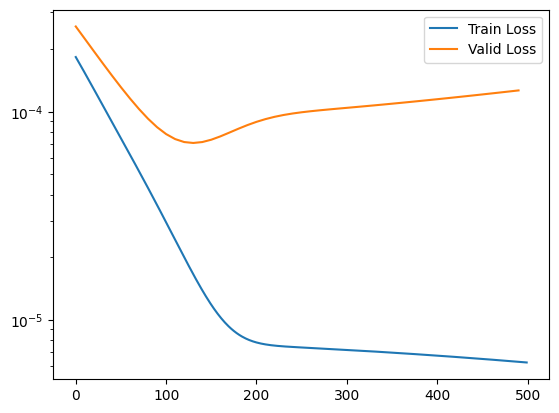

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

print(len(train_history))

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()